# Atividade Prática de Machine Learning

In [1]:
import pandas as pd

df = pd.read_csv("../data/heart_disease_dataset.csv")
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [2]:

from sklearn.preprocessing import LabelEncoder

df_transformed = df.copy()
categorical_cols = df_transformed.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_transformed[col] = le.fit_transform(df_transformed[col])
    label_encoders[col] = le

X = df_transformed.drop("Heart Disease", axis=1)
y = df_transformed["Heart Disease"]


In [3]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Report": classification_report(y_test, y_pred, output_dict=True)
    }

import pandas as pd
summary = pd.DataFrame({
    model: {
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Report"]["1"]["precision"],
        "Recall": metrics["Report"]["1"]["recall"],
        "F1-Score": metrics["Report"]["1"]["f1-score"]
    } for model, metrics in results.items()
}).T

summary


,Accuracy,Precision,Recall,F1-Score
Decision Tree,1.000000,1.000000,1.000000,1.000000
KNN,0.876667,0.889831,0.813953,0.850202
Logistic Regression,0.833333,0.831933,0.767442,0.798387


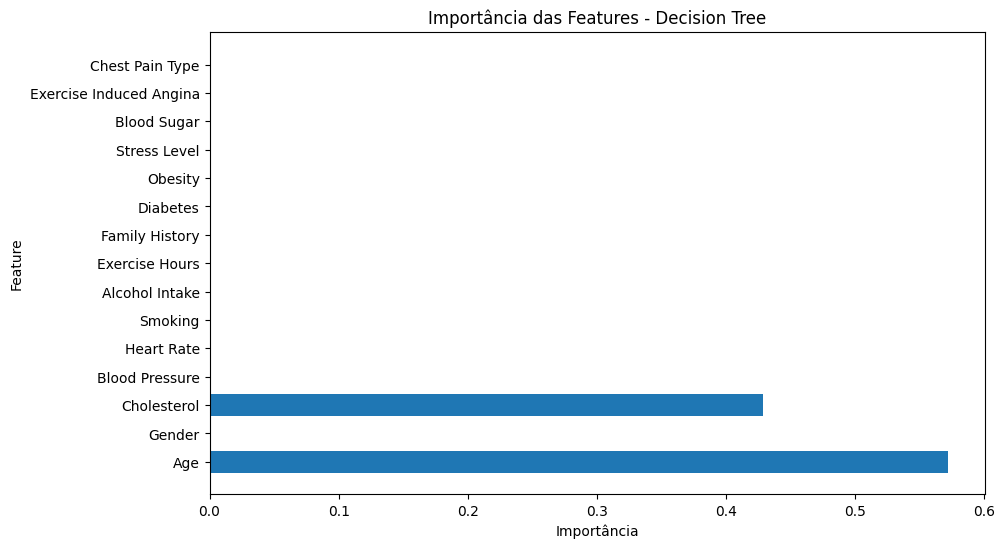

In [4]:

import matplotlib.pyplot as plt

dt_model = models["Decision Tree"]
importances = dt_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.title("Importância das Features - Decision Tree")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()
